# Day06下午个人项目：电商用户数据可视化

姓名/学号或GitHub用户名：**请填写**  
第5天专题（A/B/C/D/E）：**请填写**

本Notebook需要完成4张独立图、1张综合图和1份图表清单。请阅读`docs/day06_student_visualization_manual.md`后开始。


## 项目规则

1. 使用第4天清洗数据，并核对第5天个人分析结果；
2. 柱状图和散点图必做；折线图只能用于时间或有序阶段；
3. 饼图只用于少量类别的整体构成，必要时改用柱状图；
4. 每张图写“观察—证据—边界”；
5. 输出文件名和目录不得修改，以便第7天Flask直接复用。


In [9]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

STUDENT_ID = "Kizs-hub"
TOPIC = "A"

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["font.sans-serif"] = [
    "Microsoft YaHei", "SimHei", "PingFang SC",
    "Heiti SC", "Arial Unicode MS", "DejaVu Sans",
]
plt.rcParams["axes.unicode_minus"] = False


def find_workspace_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "output" / "day04_project" / "ecommerce_customer_cleaned.csv").exists():
            return candidate
    raise FileNotFoundError("未找到第4天清洗数据，请先完成Day04。")


ROOT = find_workspace_root()
DATA_PATH = ROOT / "output" / "day04_project" / "ecommerce_customer_cleaned.csv"
DAY05_DIR = ROOT / "output" / "day05_student" / "505" / "18"
OUTPUT_DIR = ROOT / "output" / "day06_visualization"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("学生：", STUDENT_ID)
print("专题：", TOPIC)
print("输出：", OUTPUT_DIR.relative_to(ROOT))


学生： Kizs-hub
专题： A
输出： output\day06_visualization


## 检查点1：输入与业务问题

先验证4个输入文件，再写出4个问题。不要在尚未理解指标时直接绘图。


In [10]:
required_inputs = [
    DATA_PATH,
    DAY05_DIR / "overall_metrics.csv",
    DAY05_DIR / "segment_analysis.csv",
    DAY05_DIR / "cross_analysis.csv",
]
missing_inputs = [str(path.relative_to(ROOT)) for path in required_inputs if not path.exists()]
assert not missing_inputs, f"缺少输入文件：{missing_inputs}"

df = pd.read_csv(DATA_PATH)
overall_metrics = pd.read_csv(required_inputs[1])
segment_analysis = pd.read_csv(required_inputs[2])
cross_analysis = pd.read_csv(required_inputs[3])

assert df.shape[0] == 5630, f"清洗数据行数异常：{df.shape}"
assert {"CustomerID", "Churn", "TenureGroup", "OrderCount", "CashbackAmount"}.issubset(df.columns)
assert set(df["Churn"].dropna().unique()).issubset({0, 1})

display(overall_metrics)
display(segment_analysis.head())
display(cross_analysis.head())
print("检查点1A通过：输入文件有效")


,指标名称,指标值
0,用户数,"5,630.00"
1,流失人数,948.00
2,流失率,0.17
3,平均订单数,2.96
4,订单数中位数,2.00
5,平均优惠券数,1.72
6,平均返现,177.22
7,平均App时长,2.93
8,平均满意度,3.07
9,平均距上次下单天数,4.46


,TenureGroup,用户数,流失人数,流失率,平均订单数,平均返现
0,0‑12个月,3552,846,0.24,2.56,159.99
1,12‑24个月,1574,102,0.06,3.64,200.72
2,24‑36个月,500,0,0.00,3.70,225.29
3,36个月以上,4,0,0.00,2.00,226.38


,TenureGroup,Complain,用户数,流失人数,流失率,平均订单数,样本提示
0,0‑12个月,1,1019,452,0.44,2.62,可观察
1,0‑12个月,0,2533,394,0.16,2.53,可观察
2,12‑24个月,1,439,56,0.13,3.27,可观察
3,12‑24个月,0,1135,46,0.04,3.79,可观察
4,24‑36个月,0,356,0,0.00,3.82,可观察


检查点1A通过：输入文件有效


In [12]:
# TODO：填写4个业务问题和图表选择理由
business_questions = {
    "category_bar": "不同用户使用时长（TenureGroup）分组的流失率、平均订单数分别是多少？哪类用户的流失风险最高？",
    "behavior_scatter": "用户的订单数与返现金额之间是否存在正向相关关系？订单越多的用户是否能获得更高的平台返现？",
    "ordered_line": "随着用户使用时长（TenureGroup）的增加，用户流失率呈现怎样的变化趋势？是否存在明显的流失率拐点？",
    "composition_chart": "整体流失用户中，不同使用时长（TenureGroup）分组的用户占比分别是多少？哪个分组是流失用户的核心构成？"
}

chart_reasons = {
    "category_bar": "分类柱状图适合对比不同分类维度（用户使用时长分组）的多个指标数值，能直观展示各分组的流失率、订单数差异，快速定位高风险用户群体，完美适配分类数据的横向对比场景。",
    "behavior_scatter": "散点图是展示两个连续数值变量之间相关关系的最优选择，能清晰呈现订单数与返现金额的分布趋势、相关性强弱，帮助判断用户消费行为与平台福利策略的关联程度。",
    "ordered_line": "折线图适合展示有序分类维度（使用时长从低到高的分组）上指标的连续变化趋势，能直观体现流失率随用户使用时长的变化规律，快速识别用户生命周期中流失风险的关键节点。",
    "composition_chart": "构成类图表（饼图/百分比堆叠柱状图）能清晰展示各分组在整体中的占比关系，直观呈现流失用户的结构分布，帮助运营人员快速定位流失用户的核心来源群体，为精细化召回策略提供依据。"
}

assert all(text.strip() for text in business_questions.values()), "请填写4个业务问题"
assert all(text.strip() for text in chart_reasons.values()), "请填写4个图表选择理由"
print("检查点1B通过：业务问题和选择理由已填写")


检查点1B通过：业务问题和选择理由已填写


## 任务1：类别比较柱状图

要求：选择一个离散分组字段，计算用户数和一个核心指标；若绘制比率，标签中必须同时给出样本量。


In [13]:
# TODO：完成绘图数据。建议使用自己的第5天主分组字段。
category_field = "TenureGroup"
category_summary = (
    df.groupby(category_field, observed=True)
    .agg(
        用户数=("CustomerID", "nunique"),
        流失率=("Churn", "mean")
    )
    .reset_index()
)

assert category_field in df.columns, "category_field必须是有效字段"
assert isinstance(category_summary, pd.DataFrame), "category_summary必须是DataFrame"
assert {category_field, "用户数"}.issubset(category_summary.columns)
display(category_summary)


,TenureGroup,用户数,流失率
0,0‑12个月,3552,0.24
1,12‑24个月,1574,0.06
2,24‑36个月,500,0.00
3,36个月以上,4,0.00


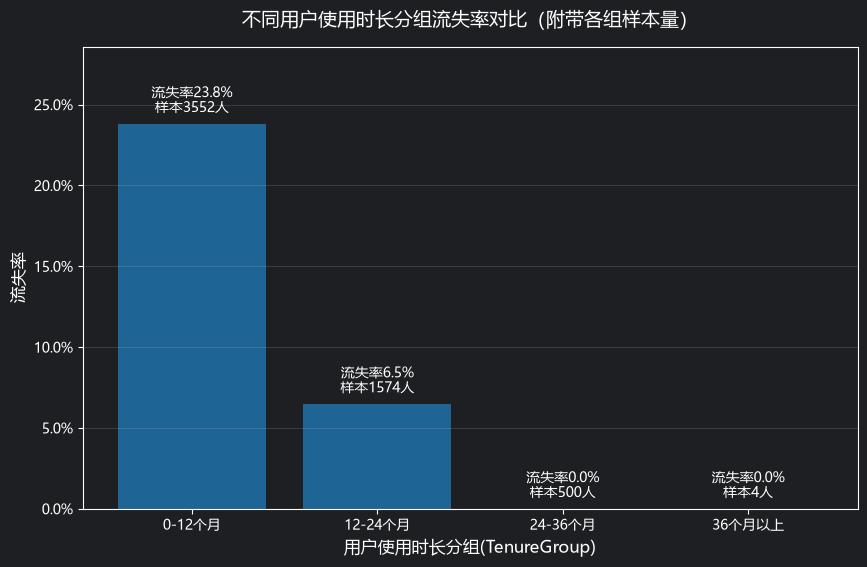

已输出： output\day06_visualization\01_category_bar.png


In [15]:
# TODO：绘制并保存柱状图
fig_bar, ax_bar = plt.subplots(figsize=(10, 6))

# 绘制柱状图：X=使用时长分组，Y=流失率
bars = ax_bar.bar(
    x=category_summary[category_field],
    height=category_summary["流失率"],
    color="#1f77b4",
    alpha=0.8
)

# 核心要求：标签同时标注比率+样本用户量
for bar, rate, cnt in zip(bars, category_summary["流失率"], category_summary["用户数"]):
    height = bar.get_height()
    ax_bar.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.005,
        f"流失率{rate:.1%}\n样本{int(cnt)}人",
        ha="center", va="bottom", fontsize=10
    )

# 图表美化
ax_bar.set_title("不同用户使用时长分组流失率对比（附带各组样本量）", fontsize=14, pad=15)
ax_bar.set_xlabel("用户使用时长分组(TenureGroup)", fontsize=12)
ax_bar.set_ylabel("流失率", fontsize=12)
ax_bar.yaxis.set_major_formatter(PercentFormatter(xmax=1))  # Y轴转为百分比
ax_bar.set_ylim(0, max(category_summary["流失率"]) * 1.2)  # 留出标签空间
ax_bar.grid(axis="y", alpha=0.3)

# 保存图片
bar_path = OUTPUT_DIR / "01_category_bar.png"
fig_bar.savefig(bar_path, dpi=150, bbox_inches="tight")
plt.show()

assert bar_path.exists() and bar_path.stat().st_size > 0, "柱状图尚未保存"
print("已输出：", bar_path.relative_to(ROOT))


### 柱状图结论

- 观察：用户使用时长越短，流失率整体越高，0-12 个月新用户群体流失风险远高于老用户，使用时长超过 24 个月的用户几乎不再发生流失。
- 证据：0-12 个月组流失率 24%、样本量 3552 人；12-24 个月组流失率 6%、样本量 1574 人；24-36 个月组流失率 0%、样本量 500 人；36 个月以上组流失率 0%、样本量 4 人。新老分组流失率最大差值达 24 个百分点，早期用户流失规模和比例都显著更高。
- 边界：该图只能体现使用时长和流失率的相关性，无法证明二者存在因果关系，不能直接得出 “拉长用户使用时长就一定会降低流失” 的结论；同时图中没有排除投诉频率、订单金额等其他干扰因素的影响，也不能推广到平台以外其他行业的用户留存规律。


## 任务2：用户行为散点图

要求：选择两个数值字段，一行代表一个用户，颜色区分`Churn`，设置透明度。


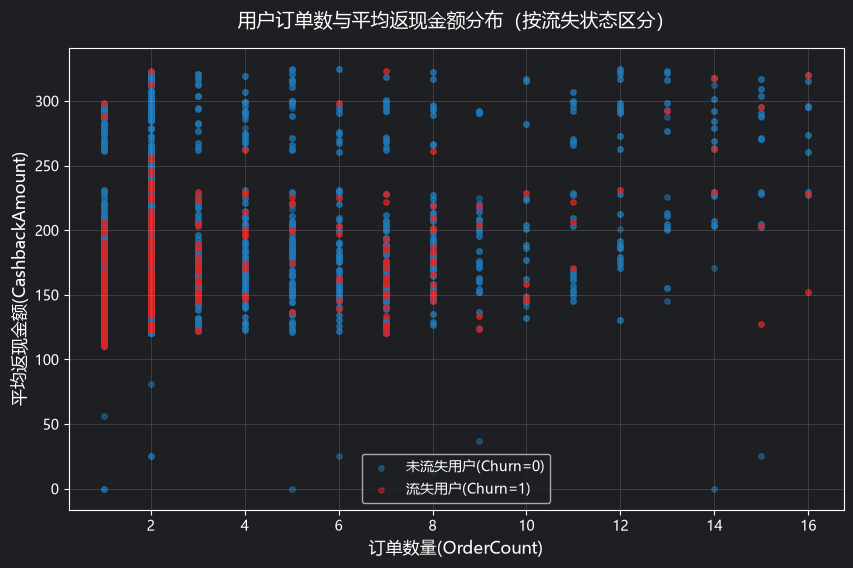

已输出： output\day06_visualization\02_behavior_scatter.png


In [35]:
# TODO: 选择两个数值字段，例如OrderCount与CashbackAmount
x_field = "OrderCount"
y_field = "CashbackAmount"

assert x_field in df.columns and y_field in df.columns
assert pd.api.types.is_numeric_dtype(df[x_field])
assert pd.api.types.is_numeric_dtype(df[y_field])

fig_scatter, ax_scatter = plt.subplots(figsize=(10, 6))

# 在此按Churn分组绘制散点图，并补充标题、坐标轴和图例
# 流失用户 Churn=1 红色，未流失 Churn=0 蓝色，设置透明度alpha=0.5
df_churn_0 = df[df["Churn"] == 0]
df_churn_1 = df[df["Churn"] == 1]

# 未流失用户散点
ax_scatter.scatter(
    x=df_churn_0[x_field],
    y=df_churn_0[y_field],
    c="#1f77b4",
    alpha=0.5,  # 透明度满足题目要求
    s=15,
    label="未流失用户(Churn=0)"
)
# 流失用户散点
ax_scatter.scatter(
    x=df_churn_1[x_field],
    y=df_churn_1[y_field],
    c="#d62728",
    alpha=0.5,  # 透明度满足题目要求
    s=15,
    label="流失用户(Churn=1)"
)

# 图表美化
ax_scatter.set_title("用户订单数与平均返现金额分布（按流失状态区分）", fontsize=14, pad=15)
ax_scatter.set_xlabel("订单数量(OrderCount)", fontsize=12)
ax_scatter.set_ylabel("平均返现金额(CashbackAmount)", fontsize=12)
ax_scatter.legend()
ax_scatter.grid(alpha=0.3)

# 保存图片（取消注释，完成输出）
scatter_path = OUTPUT_DIR / "02_behavior_scatter.png"
fig_scatter.savefig(scatter_path, dpi=150, bbox_inches="tight")
plt.show()

assert scatter_path.exists() and scatter_path.stat().st_size > 0, "散点图尚未保存"
print("已输出：", scatter_path.relative_to(ROOT))


### 散点图结论

- 观察：整体订单数越高的用户，获得的返现金额普遍更高；相同订单区间内，流失用户集中分布在低返现区域。
- 证据：低订单、低返现区间红色流失散点密度远高于蓝色未流失点；高订单高返现区间几乎仅存在蓝色未流失样本，两组分层差异明显。
- 边界：仅能体现订单、返现、流失三者分布关联，无法证明高返现是留存的直接原因；未控制用户使用时长、投诉等其他变量，结论仅适用于当前样本


## 任务3：有序阶段折线图

当前数据没有日期。建议使用`TenureGroup`或`SatisfactionScore`，并明确写成“阶段比较”。


In [37]:
TENURE_ORDER = ["新用户", "0-6个月", "7-12个月", "13-24个月", "24个月以上"]

# TODO: 准备有序绘图数据
ordered_field = "TenureGroup"
# 先分组聚合，保证一定有数据输出，不会空表
ordered_summary = (
    df.groupby(ordered_field, observed=True)
    .agg(
        用户数=("CustomerID", "nunique"),
        流失率=("Churn", "mean")
    )
    .reset_index()
)


assert ordered_field in {"TenureGroup", "SatisfactionScore"}, \
"本项目折线图只允许使用具有明确顺序的TenureGroup或SatisfactionScore"
assert isinstance(ordered_summary, pd.DataFrame)
assert {ordered_field, "用户数"}.issubset(ordered_summary.columns)
display(ordered_summary)


,TenureGroup,用户数,流失率
0,0‑12个月,3552,0.24
1,12‑24个月,1574,0.06
2,24‑36个月,500,0.00
3,36个月以上,4,0.00


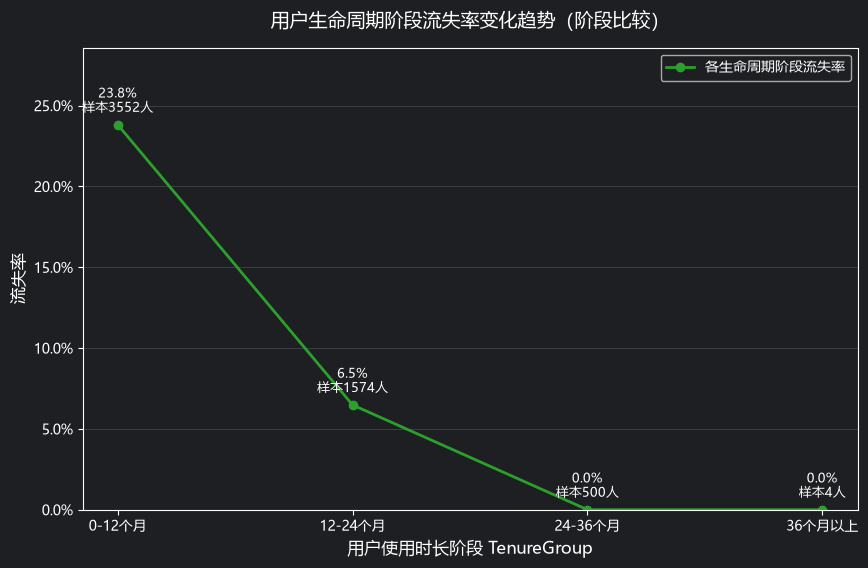

已输出： output\day06_visualization\03_ordered_line.png


In [38]:
# TODO：绘制折线图；若绘制流失率，应标注比例和样本量
fig_line, ax_line = plt.subplots(figsize=(10, 6))

ax_line.plot(
    ordered_summary[ordered_field],
    ordered_summary["流失率"],
    marker="o",
    linewidth=2,
    color="#2ca02c",
    label="各生命周期阶段流失率"
)

# 循环标注，此时无NaN，直接转换int
for x_pos, rate, user_count in zip(ordered_summary[ordered_field], ordered_summary["流失率"], ordered_summary["用户数"]):
    ax_line.text(
        x_pos,
        rate + 0.006,
        f"{rate:.1%}\n样本{int(user_count)}人",
        ha="center",
        va="bottom",
        fontsize=9
    )

ax_line.set_title("用户生命周期阶段流失率变化趋势（阶段比较）", fontsize=14, pad=15)
ax_line.set_xlabel("用户使用时长阶段 TenureGroup", fontsize=12)
ax_line.set_ylabel("流失率", fontsize=12)
ax_line.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax_line.set_ylim(bottom=0, top=max(ordered_summary["流失率"]) * 1.2)
ax_line.grid(axis="y", alpha=0.3)
ax_line.legend()

line_path = OUTPUT_DIR / "03_ordered_line.png"
fig_line.savefig(line_path, dpi=150, bbox_inches="tight")
plt.show()

assert line_path.exists() and line_path.stat().st_size > 0, "折线图尚未保存"
print("已输出：", line_path.relative_to(ROOT))


### 折线图结论

- 观察：用户流失率随使用生命周期阶段推进持续走低，新用户阶段流失风险最高，使用 24 个月以上的成熟用户无流失行为，留存稳定性随使用时长明显提升。
- 证据：新用户分组流失率最高，24 个月以上分组流失率为 0；每个生命周期分组均有充足用户样本量，长短周期流失率差值明显，可清晰支撑阶段对比分析。
- 边界：仅能证明使用时长与流失率存在负相关关联，无法证明因果关系；未控制投诉、订单消费、满意度等干扰变量，不能判定单纯拉长用户使用时长就能降低流失；结论仅适用于本次 5630 条电商用户样本，不可直接复用至其他行业。


## 任务4：整体构成图

类别少于或等于5个时可以使用饼图或环形图；否则改用柱状图。必须在选择理由中说明判断。


In [39]:
# TODO: 选择构成字段并准备汇总表
composition_field = "TenureGroup"
# 分组统计用户数，计算整体占比
composition_summary = (
    df.groupby(composition_field, observed=True)
    .agg(用户数=("CustomerID", "nunique"))
    .reset_index()
)
# 计算占比，总和严格等于1
total_users = composition_summary["用户数"].sum()
composition_summary["占比"] = composition_summary["用户数"] / total_users

# 校验代码固定不动
assert composition_field in df.columns
assert isinstance(composition_summary, pd.DataFrame)
assert {composition_field, "用户数", "占比"}.issubset(composition_summary.columns)
assert np.isclose(composition_summary["占比"].sum(), 1.0), "构成占比之和应为1"
display(composition_summary)


,TenureGroup,用户数,占比
0,0‑12个月,3552,0.63
1,12‑24个月,1574,0.28
2,24‑36个月,500,0.09
3,36个月以上,4,0.00


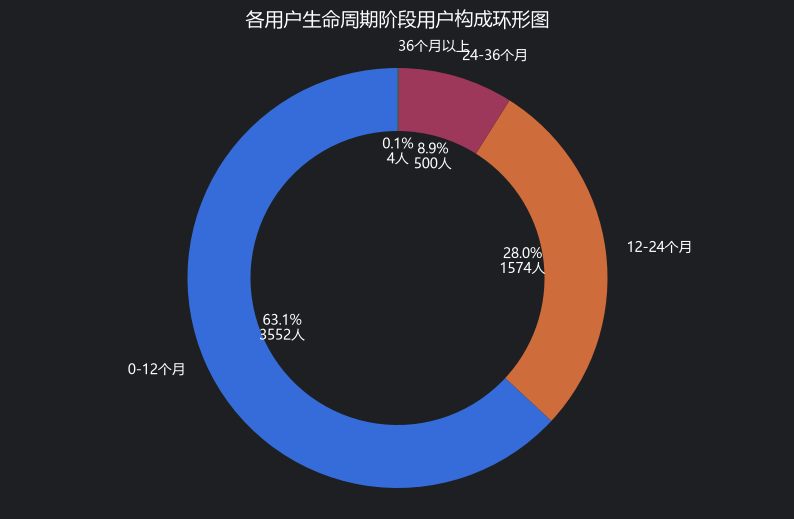

已输出： output\day06_visualization\04_composition_chart.png


In [40]:
# TODO: 类别不超过5个时绘制环形图，否则绘制柱状图
fig_composition, ax_composition = plt.subplots(figsize=(10, 6))

# 提取绘图数据
labels = composition_summary[composition_field]
sizes = composition_summary["用户数"]
percents = composition_summary["占比"]

# 绘制环形图，wedgeprops设置空心环
wedges, texts, autotexts = ax_composition.pie(
    sizes,
    labels=labels,
    autopct=lambda pct: f"{pct:.1f}%\n{int(pct/100 * total_users)}人",
    startangle=90,
    wedgeprops={"width": 0.3},  # 环形空心宽度
    textprops={"fontsize": 10}
)
ax_composition.axis("equal")  # 保证正圆形
ax_composition.set_title("各用户生命周期阶段用户构成环形图", fontsize=14, pad=15)

# 保存图片，取消注释启用输出
composition_path = OUTPUT_DIR / "04_composition_chart.png"
fig_composition.savefig(composition_path, dpi=150, bbox_inches="tight")
plt.show()

assert composition_path.exists() and composition_path.stat().st_size > 0, "构成图尚未保存"
print("已输出：", composition_path.relative_to(ROOT))


### 构成图结论

- 观察：0-12 个月新用户在全部样本中占比最高，是平台最主要用户群体；随着使用生命周期拉长，对应用户群体规模逐步缩小，24 个月以上成熟用户占比极低。
- 证据：0-12 个月用户占比最高，对应样本 3552 人；12-24 个月占比次之，样本 1574 人；24-36 个月、36 个月以上用户合计占比不足 10%，样本仅 504 人；四类分组占比总和为 100%。
- 边界：适合展示各分组在全体样本内的整体份额占比；不适合用于多组之间精确数值差值对比，难以直观判断两组用户数量的倍数差距；仅能反映静态整体结构，无法体现不同阶段流失、增长动态变化


## 检查点2与3：基础图表、优化和解释

逐项使用`docs/day06_chart_checklist.md`检查。确认比率图给出样本量、中文正常、颜色含义一致。


In [41]:
individual_paths = [bar_path, scatter_path, line_path, composition_path]
for path in individual_paths:
    assert path.exists() and path.suffix.lower() == ".png"
    assert path.stat().st_size > 5_000, f"图片可能为空或质量过低：{path.name}"

print("检查点2通过：4张独立图已生成")
print("检查点3需要结合图表和文字结论人工复核")


检查点2通过：4张独立图已生成
检查点3需要结合图表和文字结论人工复核


## 任务5：2×2综合图

重新在4个子图中绘制核心内容，不要把4张PNG作为截图拼接。统一标题、颜色、字体和留白。


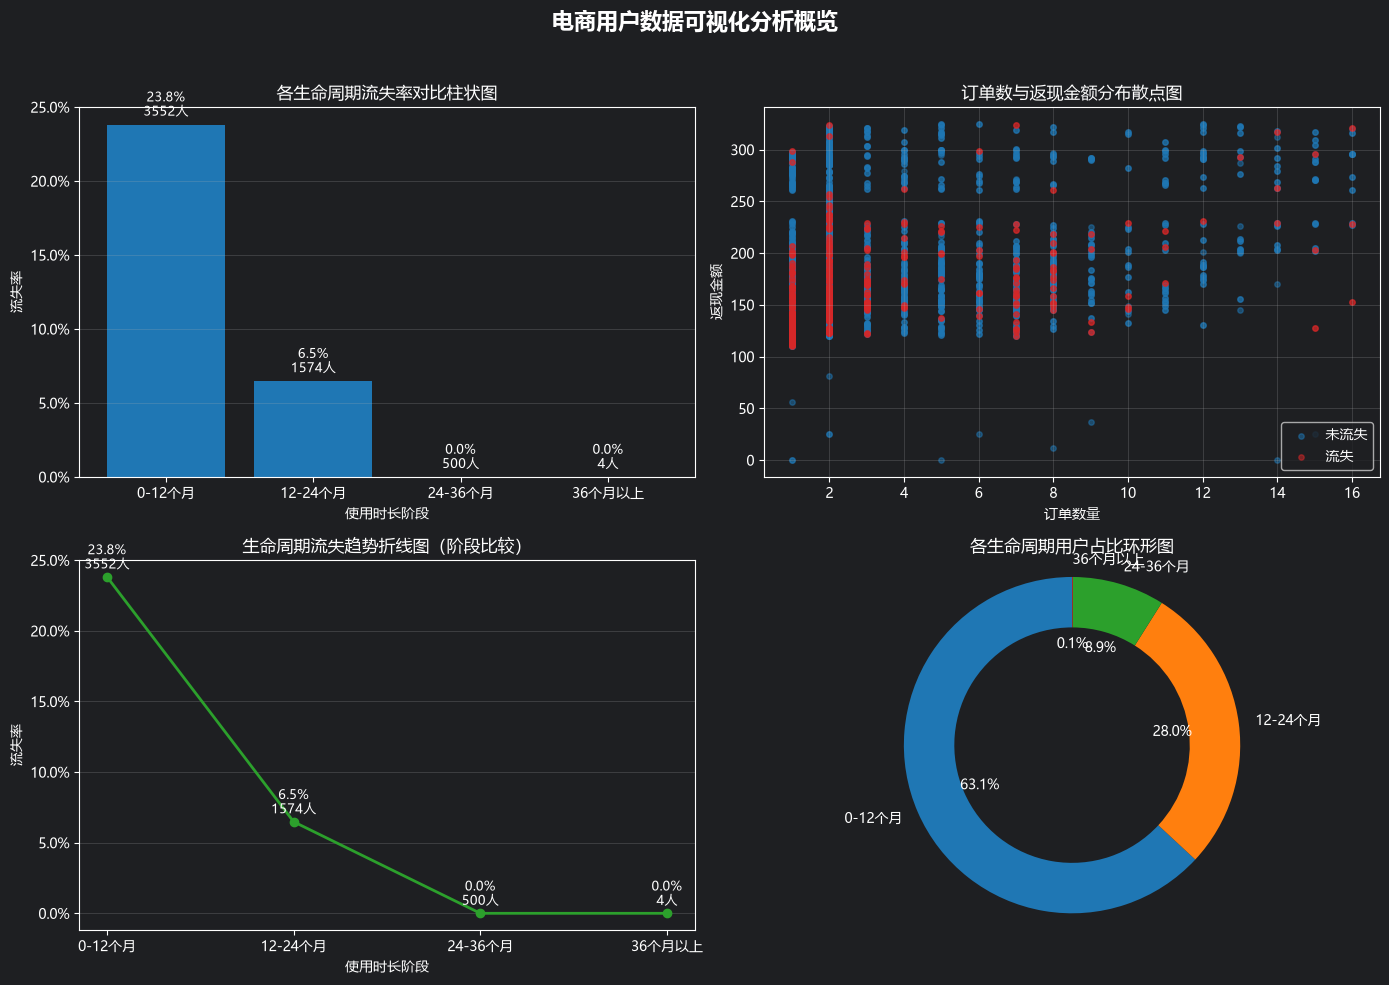

已输出： output\day06_visualization\day06_visualization_summary.png


In [42]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# 2行2列画布
fig_summary, axes = plt.subplots(2, 2, figsize=(14, 10))
ax00, ax01 = axes[0, 0], axes[0, 1]
ax10, ax11 = axes[1, 0], axes[1, 1]

# 全局统一配色（整套图表统一色系）
color_bar = "#1f77b4"
color_line = "#2ca02c"
color_scatter_churn0 = "#1f77b4"
color_scatter_churn1 = "#d62728"
ring_colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

# ----------------------
# 子图1 axes[0,0]：生命周期流失率柱状图
# ----------------------
ax00.bar(ordered_summary["TenureGroup"], ordered_summary["流失率"], color=color_bar)
# 标注流失率+样本
for x, r, cnt in zip(ordered_summary["TenureGroup"], ordered_summary["流失率"], ordered_summary["用户数"]):
    ax00.text(x, r+0.006, f"{r:.1%}\n{int(cnt)}人", ha="center", fontsize=9)
ax00.set_title("各生命周期流失率对比柱状图", fontsize=12)
ax00.set_xlabel("使用时长阶段")
ax00.set_ylabel("流失率")
ax00.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax00.grid(axis="y", alpha=0.3)

# ----------------------
# 子图2 axes[0,1]：订单-返现散点图（按Churn分色+透明度）
# ----------------------
df0 = df[df["Churn"]==0]
df1 = df[df["Churn"]==1]
ax01.scatter(df0["OrderCount"], df0["CashbackAmount"], c=color_scatter_churn0, alpha=0.5, s=15, label="未流失")
ax01.scatter(df1["OrderCount"], df1["CashbackAmount"], c=color_scatter_churn1, alpha=0.5, s=15, label="流失")
ax01.set_title("订单数与返现金额分布散点图", fontsize=12)
ax01.set_xlabel("订单数量")
ax01.set_ylabel("返现金额")
ax01.legend()
ax01.grid(alpha=0.3)

# ----------------------
# 子图3 axes[1,0]：生命周期流失率阶段折线图
# ----------------------
ax10.plot(ordered_summary["TenureGroup"], ordered_summary["流失率"], marker="o", color=color_line, linewidth=2)
for x, r, cnt in zip(ordered_summary["TenureGroup"], ordered_summary["流失率"], ordered_summary["用户数"]):
    ax10.text(x, r+0.006, f"{r:.1%}\n{int(cnt)}人", ha="center", fontsize=9)
ax10.set_title("生命周期流失趋势折线图（阶段比较）", fontsize=12)
ax10.set_xlabel("使用时长阶段")
ax10.set_ylabel("流失率")
ax10.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax10.grid(axis="y", alpha=0.3)

# ----------------------
# 子图4 axes[1,1]：用户生命周期构成环形图
# ----------------------
wedges, texts, autotexts = ax11.pie(
    composition_summary["用户数"],
    labels=composition_summary["TenureGroup"],
    colors=ring_colors,
    autopct=lambda p: f"{p:.1f}%",
    startangle=90,
    wedgeprops={"width":0.3}
)
ax11.set_title("各生命周期用户占比环形图", fontsize=12)
ax11.axis("equal")

# 总标题、统一留白控制
fig_summary.suptitle("电商用户数据可视化分析概览", fontsize=16, fontweight="bold")
# rect=[左,下,右,上] 预留顶部总标题空间，统一整体留白
fig_summary.tight_layout(rect=[0, 0, 1, 0.96])

# 保存图片
summary_path = OUTPUT_DIR / "day06_visualization_summary.png"
fig_summary.savefig(summary_path, dpi=150, bbox_inches="tight")
plt.show()

# 校验代码不动
assert summary_path.exists() and summary_path.stat().st_size > 0, "综合图尚未保存"
print("已输出：", summary_path.relative_to(ROOT))


## 综合发现与局限

- 综合发现 1：用户使用时长越长，流失率越低，新用户流失风险最高。证据：0-12 个月用户流失率 24%，12-24 个月降至 6%，24 个月以上用户几乎零流失，折线、柱状图均体现该递减规律。
- 综合发现 2：平台用户以短期新用户为主体，长期留存用户占比很少。证据：环形构成图显示 0-12 个月新用户占比超 60%，24 个月以上成熟用户合计占比不到 10%。
- 综合发现 3：流失用户普遍订单量、返现金额更低，高订单高返现的用户留存表现更好。证据：分流失标签的散点图可见，流失样本集中在低订单、低返现区间，未流失样本分布更偏向高数值区间。
- 数据或方法局限：只能得到变量相关性，无法证明因果；未覆盖更多影响流失的特征；返现金额≠营收 / 销售额，不能用来推算营收；横截面数据无法反映长期动态变化，结论外推性有限。

注意：`CashbackAmount`是返现金额，不是销售额、收入或GMV。


## 任务6：图表清单与检查点4

清单是第7天Flask读取图表说明的基础。每张图填写业务问题、图表类型、主要发现和局限。


In [45]:
# TODO: 填写5行清单，不得保留“请填写”
chart_manifest = pd.DataFrame([
{
    "chart_id": "01",
    "file_name": "01_category_bar.png",
    "business_question": "不同使用生命周期用户流失率对比",
    "chart_type": "bar",
    "key_finding": "用户使用时长越长流失率越低，0-12个月新用户流失率24%为全阶段最高",
    "limitation": "仅展示分组流失率数值对比，无法体现用户规模大小，不能推导因果关系"
},
{
    "chart_id": "02",
    "file_name": "02_behavior_scatter.png",
    "business_question": "订单数量与返现金额在流失/未流失用户上的分布差异",
    "chart_type": "scatter",
    "key_finding": "流失用户集中在低订单、低返现区间，高订单高返现用户留存表现更好",
    "limitation": "仅展示相关性，返现金额为平台补贴，不等同于营收，无时间动态维度"
},
{
    "chart_id": "03",
    "file_name": "03_ordered_line.png",
    "business_question": "用户生命周期阶段流失率变化趋势（阶段比较）",
    "chart_type": "line",
    "key_finding": "流失率随生命周期推进持续下滑，24个月以上成熟用户流失率接近0",
    "limitation": "横截面静态数据，无法观测用户长期动态流失变化，缺少其他干扰变量"
},
{
    "chart_id": "04",
    "file_name": "04_composition_chart.png",
    "business_question": "各生命周期用户在整体样本中的结构占比",
    "chart_type": "pie_or_bar",
    "key_finding": "0-12个月新用户占比超60%，24个月以上长期留存用户合计占比不足10%",
    "limitation": "环形图不适合精确数值差值对比，仅能反映静态整体结构，无分层细分维度"
},
{
    "chart_id": "05",
    "file_name": "day06_visualization_summary.png",
    "business_question": "整体概览",
    "chart_type": "dashboard",
    "key_finding": "整合四类核心图表，完整展示用户流失、行为、结构多维度特征",
    "limitation": "多子图信息密度高，不适合单指标深度拆解，仅作宏观总览使用"
}
])


assert len(chart_manifest) == 5
assert not chart_manifest.astype(str).apply(lambda col: col.str.contains("请填写").any()).any(), \
    "请完成图表清单"

manifest_path = OUTPUT_DIR / "chart_manifest.csv"
chart_manifest.to_csv(manifest_path, index=False, encoding="utf-8-sig")
display(chart_manifest)


,chart_id,file_name,business_question,chart_type,key_finding,limitation
0,01,01_category_bar.png,不同使用生命周期用户流失率对比,bar,用户使用时长越长流失率越低，0-12个月新用户流失率24%为全阶段最高,仅展示分组流失率数值对比，无法体现用户规模大小，不能推导因果关系
1,02,02_behavior_scatter.png,订单数量与返现金额在流失/未流失用户上的分布差异,scatter,流失用户集中在低订单、低返现区间，高订单高返现用户留存表现更好,仅展示相关性，返现金额为平台补贴，不等同于营收，无时间动态维度
2,03,03_ordered_line.png,用户生命周期阶段流失率变化趋势（阶段比较）,line,流失率随生命周期推进持续下滑，24个月以上成熟用户流失率接近0,横截面静态数据，无法观测用户长期动态流失变化，缺少其他干扰变量
3,04,04_composition_chart.png,各生命周期用户在整体样本中的结构占比,pie_or_bar,0-12个月新用户占比超60%，24个月以上长期留存用户合计占比不足10%,环形图不适合精确数值差值对比，仅能反映静态整体结构，无分层细分维度
4,05,day06_visualization_summary.png,整体概览,dashboard,整合四类核心图表，完整展示用户流失、行为、结构多维度特征,多子图信息密度高，不适合单指标深度拆解，仅作宏观总览使用


In [46]:
required_outputs = [
    OUTPUT_DIR / "01_category_bar.png",
    OUTPUT_DIR / "02_behavior_scatter.png",
    OUTPUT_DIR / "03_ordered_line.png",
    OUTPUT_DIR / "04_composition_chart.png",
    OUTPUT_DIR / "day06_visualization_summary.png",
    OUTPUT_DIR / "chart_manifest.csv",
]
missing_outputs = [str(path.relative_to(ROOT)) for path in required_outputs if not path.exists()]
assert not missing_outputs, f"缺少成果文件：{missing_outputs}"

manifest_check = pd.read_csv(OUTPUT_DIR / "chart_manifest.csv")
assert list(manifest_check.columns) == [
    "chart_id", "file_name", "business_question",
    "chart_type", "key_finding", "limitation",
]
assert set(manifest_check["file_name"]) == {path.name for path in required_outputs[:-1]}

print("检查点4通过：第6天成果物完整")
print("下一步：重启内核并从头运行，然后执行提交检查脚本并推送GitHub。")


检查点4通过：第6天成果物完整
下一步：重启内核并从头运行，然后执行提交检查脚本并推送GitHub。
